# Read Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style()
warnings.filterwarnings("ignore")

In [2]:
df_train = pd.read_csv("/kaggle/input/notebooks/davidvista/data-preparation-modeling/train_aug.csv")
df_test = pd.read_csv("/kaggle/input/notebooks/davidvista/data-preparation-modeling/test_aug.csv")
df_emerging = pd.read_csv("/kaggle/input/notebooks/davidvista/data-preparation-modeling/emerging_aug.csv")

In [3]:
df_train.head(5)

,author_playtime_last_two_weeks,author_num_reviews,author_num_games_owned,author_playtime_forever,weighted_vote_score,total_games,avg_initial_price,avg_discount_percent,avg_achievement_count,avg_languages,years_past_first_release,release_frequency,percent_free,genre_count,category_count,is_top,cluster_premium_discounters,cluster_hardcore_niche,cluster_high_volume_diversified,cluster_free_to_play
0,0.000000,24.333333,416.000000,8.000000,0.551310,1,0.000000,0.000000,20.000000,1.000000,7,0.125000,1.0,1,1,0,0,0,0,1
1,0.000000,247.000000,1011.500000,26.500000,0.564949,6,5.990000,0.000000,20.000000,1.000000,4,1.200000,0.0,2,3,0,0,0,0,0
2,58.230769,38.692308,68.000000,280.923077,0.503663,44,17.080910,0.695455,18.181818,9.454545,5,7.333333,0.0,3,12,0,1,0,0,0
3,0.000000,738.607843,1340.666667,447.941176,0.534286,116,1.783103,0.077586,21.482759,1.000000,6,16.571429,0.0,7,9,0,0,0,1,0
4,0.000000,67.000000,602.000000,5.000000,0.525547,9,3.990000,0.000000,20.000000,1.000000,7,1.125000,0.0,3,3,0,0,0,0,0


In [4]:
import shap
import matplotlib.pyplot as plt

def shap_importance(model, X, feature_names=None, plot=True):
    """SHAP feature importance for any model with predict_proba."""
    def f(x):
        return model.predict_proba(x)[:, 1]
    explainer = shap.Explainer(f, X)
    shap_values = explainer(X)
    if plot:
        shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
        plt.show()
    return explainer, shap_values

In [5]:
def shap_bar_plot(shap_values, feature_names=None, max_display=20, figsize=(10, 6)):
    """
    Bar plot of mean absolute SHAP values per feature.
    
    Parameters
    ----------
    shap_values : shap.Explanation or array-like
        SHAP values (output from shap.Explainer).
    feature_names : list, optional
        List of feature names.
    max_display : int
        Maximum number of features to display.
    figsize : tuple
        Figure size.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    if hasattr(shap_values, 'values'):
        shap_vals = shap_values.values
    else:
        shap_vals = shap_values
    
    # Compute mean absolute SHAP per feature
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    
    # Sort descending
    idx = np.argsort(mean_abs_shap)[::-1][:max_display]
    features = [feature_names[i] if feature_names else f"Feature {i}" for i in idx]
    values = mean_abs_shap[idx]
    
    plt.figure(figsize=figsize)
    plt.barh(features[::-1], values[::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title("Feature Importance (SHAP)")
    plt.tight_layout()
    plt.show()

# Fit Model

In [6]:
from sklearn.preprocessing import RobustScaler

y_train = df_train['is_top'].to_numpy().copy()
X_train = df_train.drop(columns=['is_top']).to_numpy().copy()

In [7]:
rf_best_params = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 4,
    'max_features': 'sqrt',
    'bootstrap': True,
    'class_weight': 'balanced',
    'n_jobs': -1,
    'random_state': 0
}

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_best_model = RandomForestClassifier(**rf_best_params)
rf_best_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=4,
                       n_estimators=300, n_jobs=-1, random_state=0)

In [9]:
rf_threshold = 0.6263

In [10]:
y_test = df_test['is_top'].copy()
X_test = df_test.drop(columns=['is_top']).copy()

feature_names = list(df_test.drop(columns=['is_top']).columns)

In [11]:
# rf_shap_values = shap_importance(rf_best_model, X_test, feature_names)

In [12]:
# shap_bar_plot(rf_shap_values, feature_names=feature_names)

In [13]:
# mean_abs_shap = np.mean(np.abs(rf_shap_values.values), axis=0)
# threshold = np.max(mean_abs_shap) * 0.01
# important_features = mean_abs_shap >= threshold
# print(f"Number of important features: {np.sum(important_features)}")

# Emerging Developers Search Evaluation

In [14]:
import pandas as pd
import numpy as np

def evaluate_emerging_ranking(y_pred_proba, X_test, probability_threshold=0.7):
    """
    Evaluate whether at least 5 emerging non‑top developers have predicted probability
    above the given threshold (default 0.7). Returns a report of those developers.

    Parameters
    ----------
    y_pred_proba : array-like
        Predicted probabilities for the test set (positive class).
    X_test : pd.DataFrame
        Test set DataFrame. Must contain columns:
        - 'years_past_first_release'
        - 'is_top'
    probability_threshold : float, default=0.7
        The absolute probability threshold considered as "enough evidence".

    Returns
    -------
    report : pd.DataFrame
        Table of emerging non‑top developers with probability > threshold, sorted descending.
    success : bool
        True if at least 5 such developers exist.
    """
    # Identify emerging non‑top developers
    emerging_mask = (X_test['years_past_first_release'] <= 3) & (X_test['is_top'] == 0)
    if not emerging_mask.any():
        print("No emerging non‑top developers in the test set.")
        return None, False

    # Get their predicted probabilities
    emerging_proba = y_pred_proba[emerging_mask]
    emerging_indices = emerging_mask[emerging_mask].index

    # Keep only those with probability > threshold
    high_conf_mask = emerging_proba > probability_threshold
    high_conf_indices = emerging_indices[high_conf_mask]
    high_conf_proba = emerging_proba[high_conf_mask]

    # Sort descending by probability
    sort_idx = np.argsort(high_conf_proba)[::-1]
    sorted_indices = high_conf_indices[sort_idx]
    sorted_proba = high_conf_proba[sort_idx]

    # Build report
    report_data = []
    for i, (idx, proba) in enumerate(zip(sorted_indices, sorted_proba), 1):
        report_data.append({
            'Rank': i,
            'Developer ID': idx,
            'Predicted Probability': f"{proba:.3f}"
        })

    report_df = pd.DataFrame(report_data)
    success = len(report_df) >= 5

    print(f"Found {len(report_df)} emerging non‑top developers with probability > {probability_threshold}")
    if success:
        print("Business success criterion met: at least 5 developers have sufficient evidence.")
    else:
        print("Business success criterion NOT met.")

    return report_df, success

In [15]:
df_rank = df_emerging[df_emerging['is_top'] == 0]

In [16]:
y_rank = df_rank['is_top'].copy()
X_rank = df_rank.drop(columns=['is_top']).copy()

In [17]:
y_test_pred_proba = rf_best_model.predict_proba(X_rank)[:, 1]

print("Random Forest:")
report, success = evaluate_emerging_ranking(y_test_pred_proba, df_rank, probability_threshold=0.7)
print("Passed the business success criterion" if success else "Failed to pass the business success criterion")
print()

Random Forest:
Found 49 emerging non‑top developers with probability > 0.7
Business success criterion met: at least 5 developers have sufficient evidence.
Passed the business success criterion



In [18]:
# Get top 10 emerging developers by predicted probability
probs = rf_best_model.predict_proba(X_rank)[:, 1]
top10_idx = np.argsort(probs)[::-1][:10]
top10_probs = probs[top10_idx]
top10_data = X_rank.iloc[top10_idx]

top10_probs

array([0.84083608, 0.83297209, 0.79843844, 0.79622889, 0.78698462,
       0.78601273, 0.7850675 , 0.7751815 , 0.77397952, 0.77146968])

In [19]:
import shap

# Use a small background sample from training data for efficiency
background = df_train.drop(columns=['is_top']).copy().sample(n=100, random_state=0)

explainer = shap.TreeExplainer(rf_best_model, background, feature_names=feature_names)
shap_values = explainer(background, check_additivity=False)

 98%|===================| 196/200 [00:31<00:00]       

In [20]:
shap_values_top10 = explainer(top10_data, check_additivity=False)

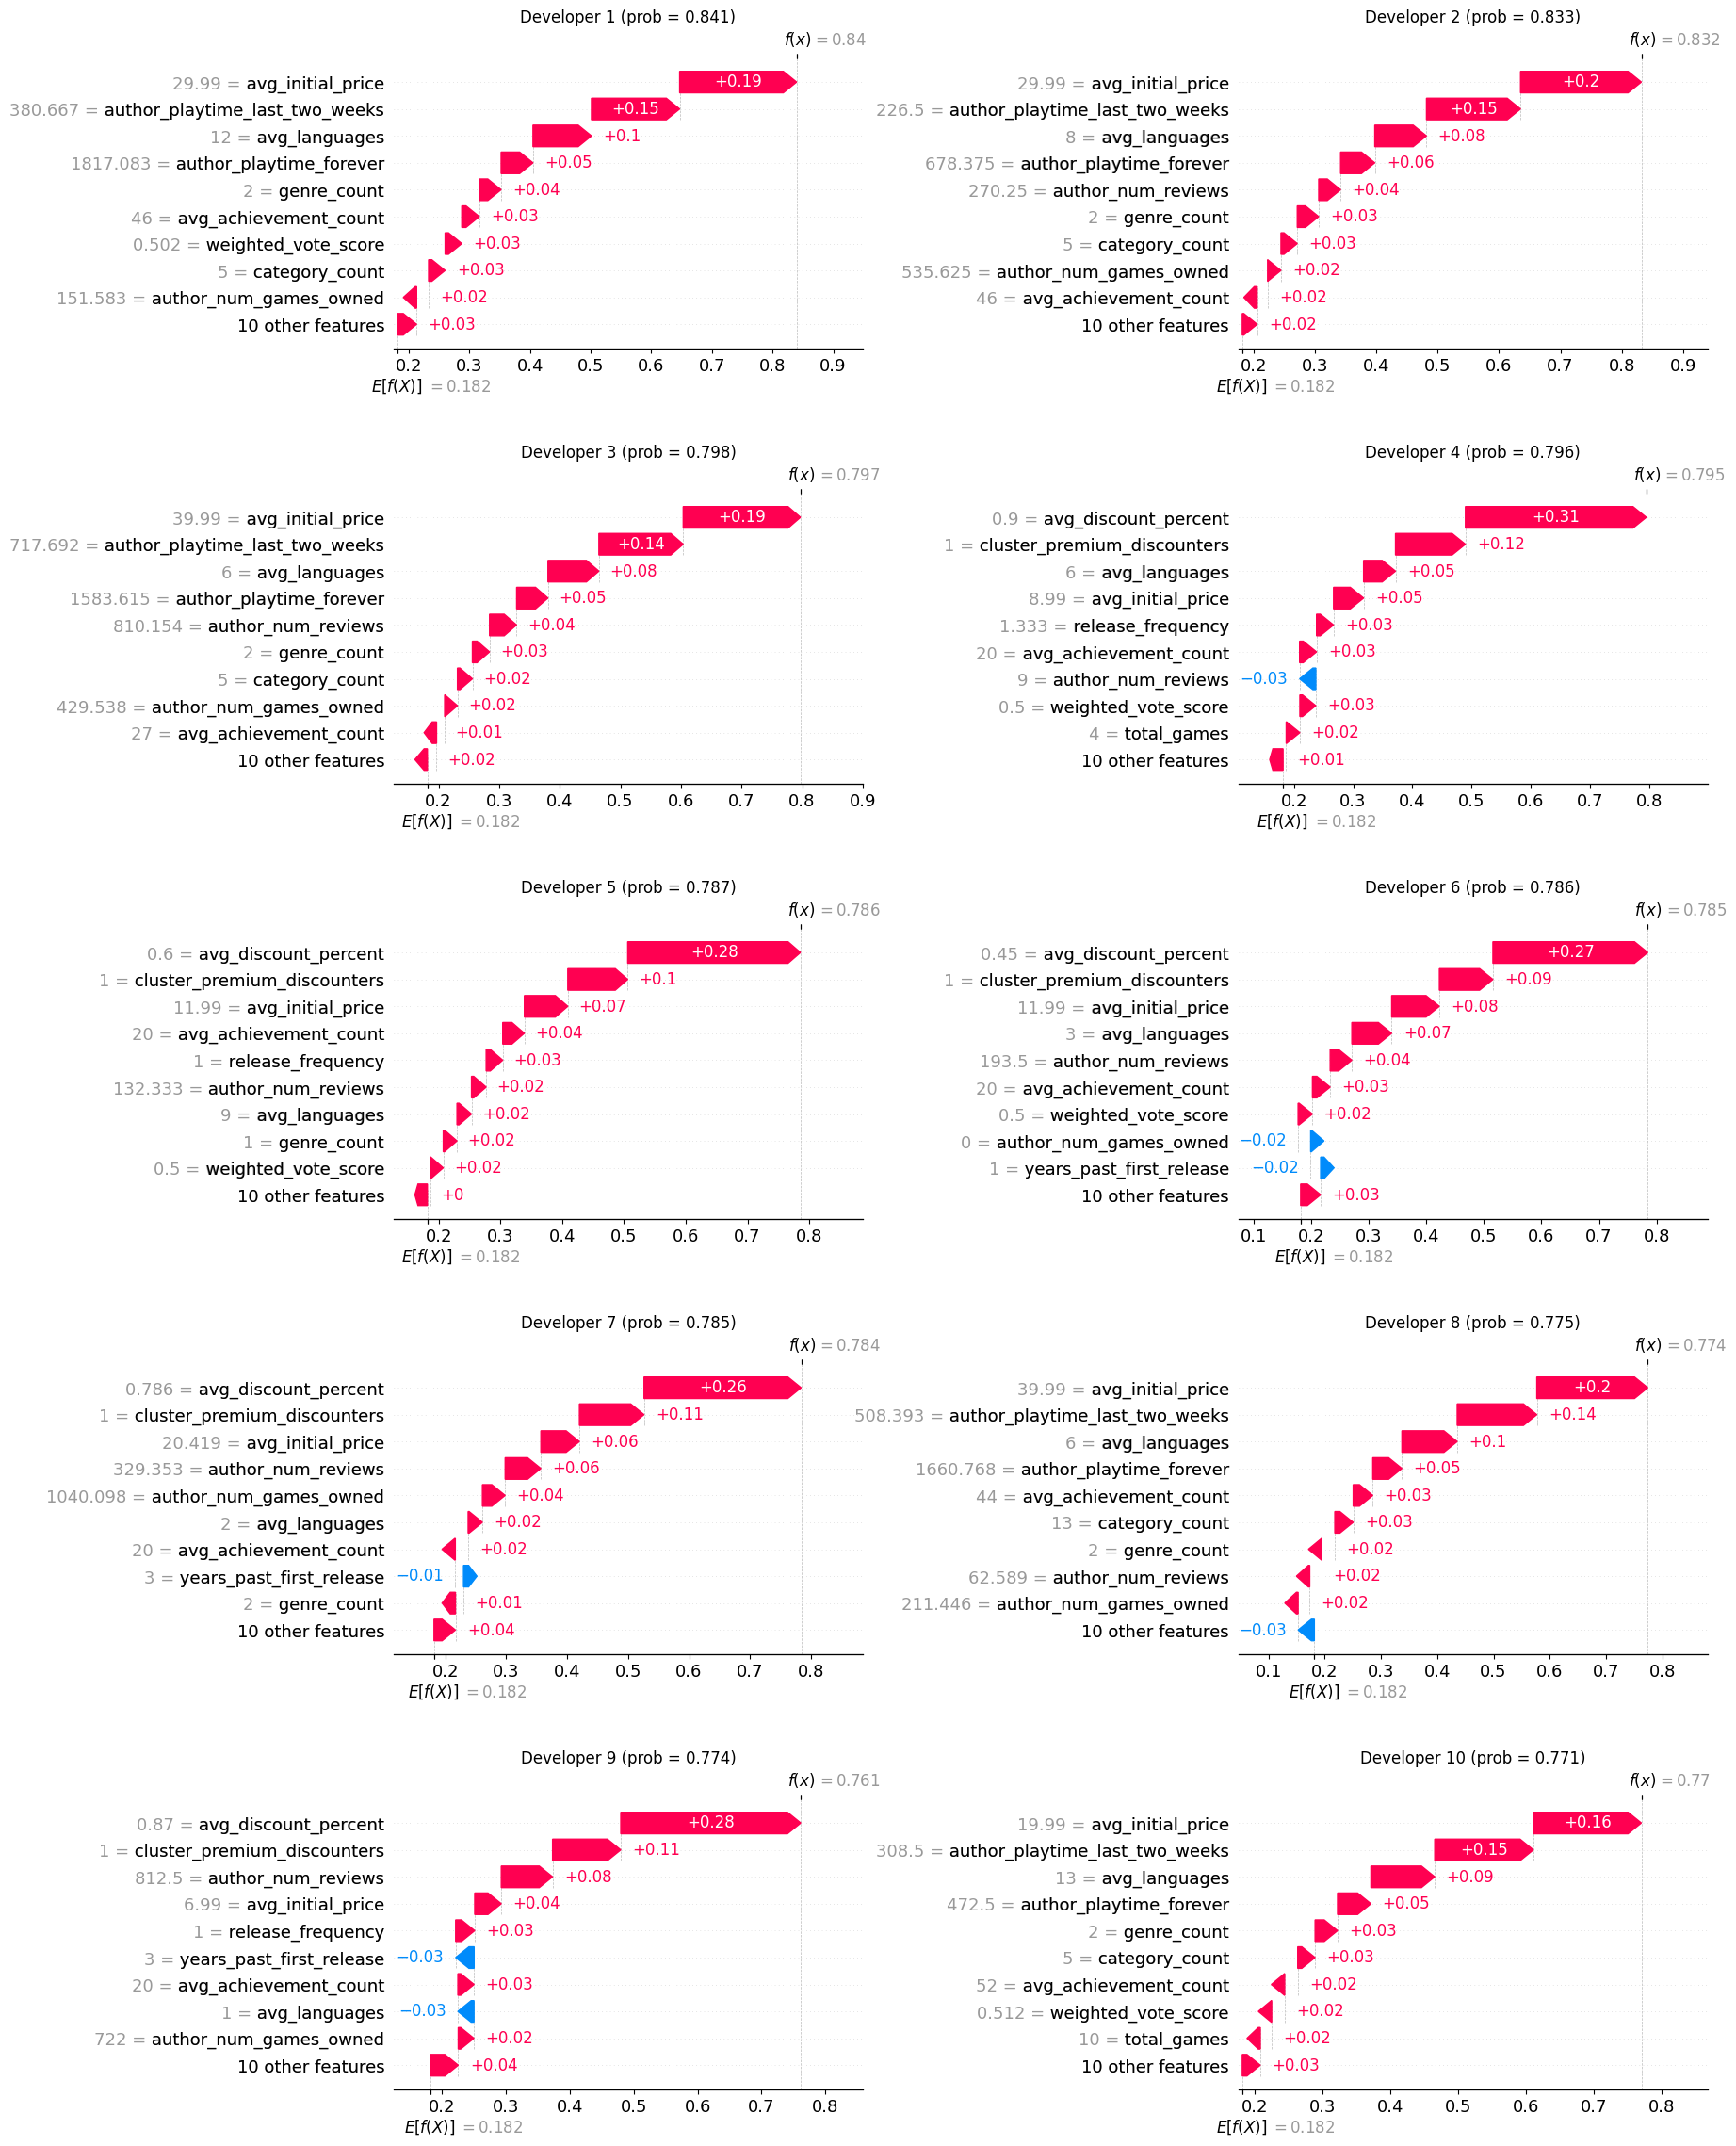

In [21]:
import matplotlib.pyplot as plt
import shap

# Create the grid (figsize will be overridden later)
fig, axes = plt.subplots(5, 2)
axes = axes.flatten()

for i, ax in enumerate(axes):
    exp = shap_values_top10[i, :, 1]          # Explanation for class 1
    plt.sca(ax)
    shap.plots.waterfall(exp, show=False)
    ax.set_title(f"Developer {i+1} (prob = {top10_probs[i]:.3f})")

# Adjust overall figure size and spacing
fig.set_size_inches(18, 28)                  # width, height
plt.subplots_adjust(hspace=0.5, wspace=0.8)  # vertical & horizontal gaps
fig.savefig('shap_waterfall_grid.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# After computing shap_values_top10 (shape: 10, n_features) and explainer
feature_names = X_rank.columns.tolist()
base_value = shap_values_top10.base_values[0, 1]

for i in range(10):
    shap_vals = shap_values_top10.values[i][:, 1]
    # Create a DataFrame of feature contributions
    contrib_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': shap_vals
    })
    # Sort by absolute contribution descending
    contrib_df = contrib_df.reindex(contrib_df['shap_value'].abs().sort_values(ascending=False).index)
    
    print(f"\nDeveloper {i+1} (predicted probability = {top10_probs[i]:.3f}, base value = {base_value:.3f})")
    print("Positive contributions (increase probability):")
    pos = contrib_df[contrib_df['shap_value'] > 0].head(10)
    for _, row in pos.iterrows():
        print(f"  {row['feature']}: +{row['shap_value']:.3f}")
    print("Negative contributions (decrease probability):")
    neg = contrib_df[contrib_df['shap_value'] < 0].head(10)
    for _, row in neg.iterrows():
        print(f"  {row['feature']}: {row['shap_value']:.3f}")
    print(f"Sum of SHAP values: {shap_vals.sum():.3f}, Predicted probability: {base_value + shap_vals.sum():.3f}")


Developer 1 (predicted probability = 0.841, base value = 0.182)
Positive contributions (increase probability):
  avg_initial_price: +0.193
  author_playtime_last_two_weeks: +0.145
  avg_languages: +0.096
  author_playtime_forever: +0.053
  genre_count: +0.036
  avg_achievement_count: +0.029
  weighted_vote_score: +0.027
  category_count: +0.027
  author_num_games_owned: +0.020
  total_games: +0.017
Negative contributions (decrease probability):
  years_past_first_release: -0.011
  avg_discount_percent: -0.009
  cluster_premium_discounters: -0.001
  cluster_hardcore_niche: -0.000
Sum of SHAP values: 0.658, Predicted probability: 0.840

Developer 2 (predicted probability = 0.833, base value = 0.182)
Positive contributions (increase probability):
  avg_initial_price: +0.197
  author_playtime_last_two_weeks: +0.153
  avg_languages: +0.084
  author_playtime_forever: +0.056
  author_num_reviews: +0.036
  genre_count: +0.035
  category_count: +0.027
  author_num_games_owned: +0.022
  avg_ach